# Data Profiling 
This section assesses the dataset's structure, quality, and potential issues.

**Data Loading & Date Parsing**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv file
df = pd.read_csv('../data/kenya.csv') 
# Add Country Column
df['Country'] = 'Kenya'
# create a dat from the year and DOY
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
#extracting a month from the year and the DOY
df['Month'] = df['Date'].dt.month
# Check the results
print(df[['YEAR', 'DOY',  'Month']].tail())



      YEAR  DOY  Month
4103  2026   86      3
4104  2026   87      3
4105  2026   88      3
4106  2026   89      3
4107  2026   90      3


**Summary Statistics & Missing-Value Report**

In [33]:
# Check how many rows and features columns we have
print("Data Shape:", df.shape) 
#  Handle NASA Sentinel Values
df.replace(-999, np.nan, inplace=True)
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Data Shape: (4108, 15)
Total Duplicate Rows Found: 0


**Duplicate check**

0 duplicate rows were detected across all 4,108 observations.

Therefore, No data removal was required showing that each record in the Ethiopia dataset represents a unique observation.

In [34]:

# Generate the 5-number summary (count, mean, std, min, max)
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


**Statistical Interpretation of Climate Variables**

Temperature (T2M): Kenya is temperature on average at 20.43°C. The temperature is very stable (standard deviation of only 1.44), staying mostly between 15.26°C and 25.40°C.  the mean and median are nearly identical, showing a very balanced temperature distribution.

Daily Temp Change (T2M_RANGE): There is a consistent daily swing of about 13.17°C. Even on the most stable days, the temperature changes by at least 4.11°C, showing that day-to-night transitions are a major part of the climate here.

Rainfall (PRECTOTCORR): The rainfall pattern is extreme. The average is only 1.47 mm, but the median is a tiny 0.38 mm. This means most days have almost no rain, but occasional massive storms (up to 51.65 mm) pull the average up.

Humidity and Wind (RH2M & WS2M): Average humidity is 65.8%,the wind is fairly strong, averaging 3.06 m/s with gusts reaching 7.59 m/s.

Surface Pressure (PS): The pressure averages 83.72 kPa, which suggests this specific region of Kenya is likely at a lower altitude.

In [35]:
# Check for Missing Values
print("\n--- Missing Value Count ---")
print(df.isna().sum())
missing_values = df.isna().sum()
missing_pct = (missing_values / len(df)) * 100


--- Missing Value Count ---
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


The missing value analysis shows the Kenya dataset contains 0% null values across all columns.

What this means for the analysis: Since no columns exceed the 5% threshold. We do not need to fill any gaps. 

**Outlier Detection & Basic Cleaning**



In [ ]:
#  Z-Score
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols].dropna()))

# Flagging outliers
outliers_count = (z_scores > 3).sum(axis = 0)
print("Outlier counts per column (|Z| > 3):")
print(outliers_count)

Outlier counts per column (|Z| > 3):
[ 8  3  9 92  6  0  6]


**Outlier Detection**

In total we have 124 outliers across the given columns. 

It has been chosen to retain the 124 identified outliers because,

 In a climate dataset, extreme values represent important weather events like storms and heatwaves. Most of these outliers are in the Rainfall (PRECTOTCORR) column. This is expected because rain happens in sudden bursts, and these spikes are a real part of the average.

Out of 4,108 observations, these 124 outliers make up less than 0.5% of the data. Keeping them protects the natural variety of the climate record without hurting the accuracy of our trend analysis.

In [37]:
# Handling Strategy
# Forward-fill for weather variables to maintain time-series continuity
df[target_cols] = df[target_cols].ffill()

# Export Cleaned Data and the data folder is in gitignore
df.to_csv('../data/kenya_clean.csv', index=False)

**Time Series Analysis**

***Monthly Temperature Trends (2015–2026)***

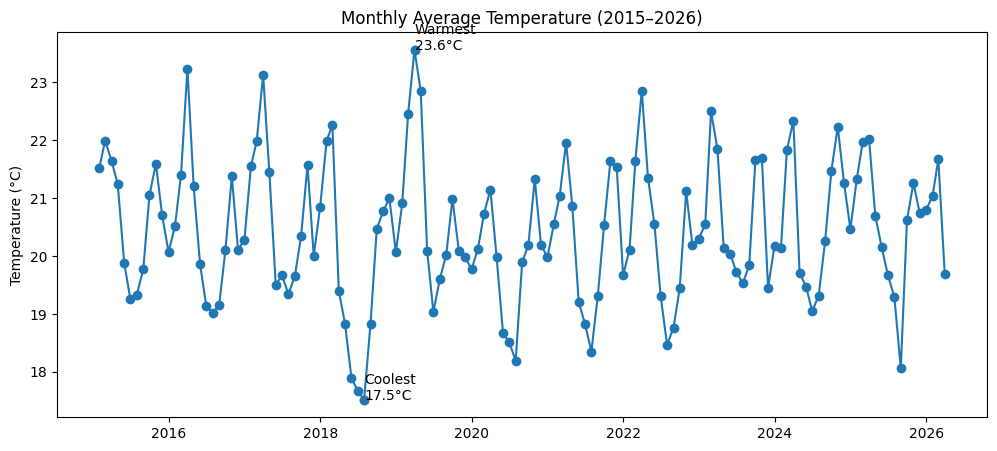

In [38]:
# Resample to monthly averages
monthly_temp = df.set_index('Date').resample('ME')['T2M'].mean().reset_index()

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], marker='o')

# Annotate
plt.scatter(warmest['Date'], warmest['T2M'])
plt.text(warmest['Date'], warmest['T2M'], f"Warmest\n{warmest['T2M']:.1f}°C")

plt.scatter(coolest['Date'], coolest['T2M'])
plt.text(coolest['Date'], coolest['T2M'], f"Coolest\n{coolest['T2M']:.1f}°C")

plt.title('Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.show()

The line chart shows repeating wave pattern in temperature, demonstrating consistent seasonal transitions. The data shows a big gap of 6.1°C between the hottest month (23.6°C in early 2019) and the coldest month (17.5°C in mid-2018). It mostly stays between 18°C and 23°C without getting much hotter or colder overall.

**Monthly Total Precipitation**

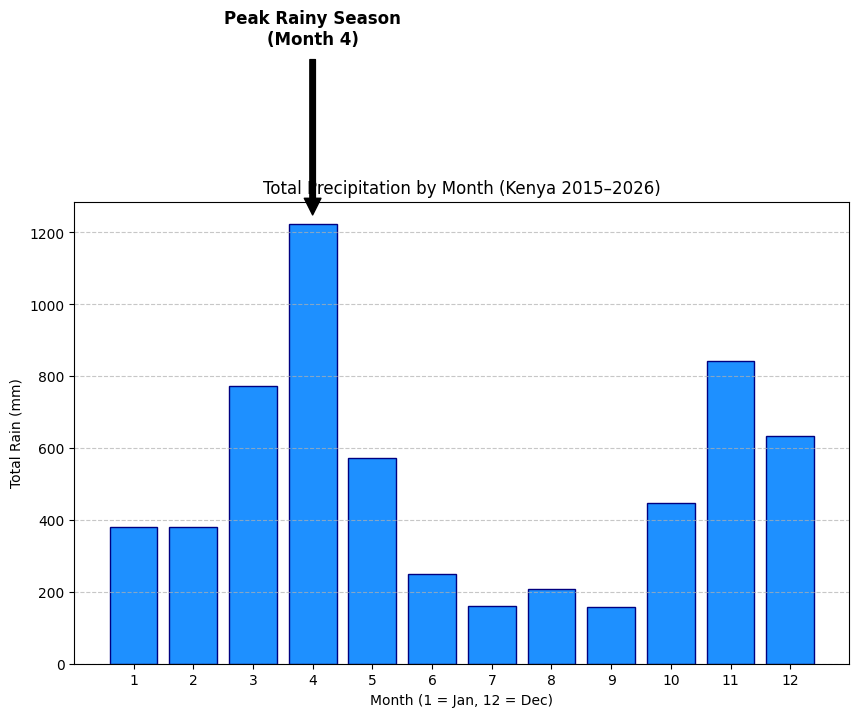

In [39]:
# 1. Group by Month (1-12) to get the total rain for that month across all years
seasonal_rain = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

# 2. Find the peak month for annotation
peak_val = seasonal_rain['PRECTOTCORR'].max()
peak_month_num = seasonal_rain.loc[seasonal_rain['PRECTOTCORR'].idxmax(), 'Month']

# 3. Plotting
plt.figure(figsize=(10, 6))
# We use seasonal_rain['Month'] as the X-axis so we get 12 clean bars
plt.bar(seasonal_rain['Month'], seasonal_rain['PRECTOTCORR'], color='dodgerblue', edgecolor='navy')

# 4. Annotation (Identifying the peak)
plt.annotate(f'Peak Rainy Season\n(Month {int(peak_month_num)})', 
             xy=(peak_month_num, peak_val), 
             xytext=(peak_month_num, peak_val + 500),
             ha='center',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Total Precipitation by Month (Kenya 2015–2026)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Rain (mm)')
plt.xticks(range(1, 13)) # Show every month number
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows two high points for rain. This means there are two rainy seasons. The rain builds up to its highest point in April (Month 4), which is the main rainy season. A second, smaller rainy time happens in November (Month 11). The months in between (especially July, August, and September) have very little rain, which marks the dry season.

**Correlation & Relationship Analysis**

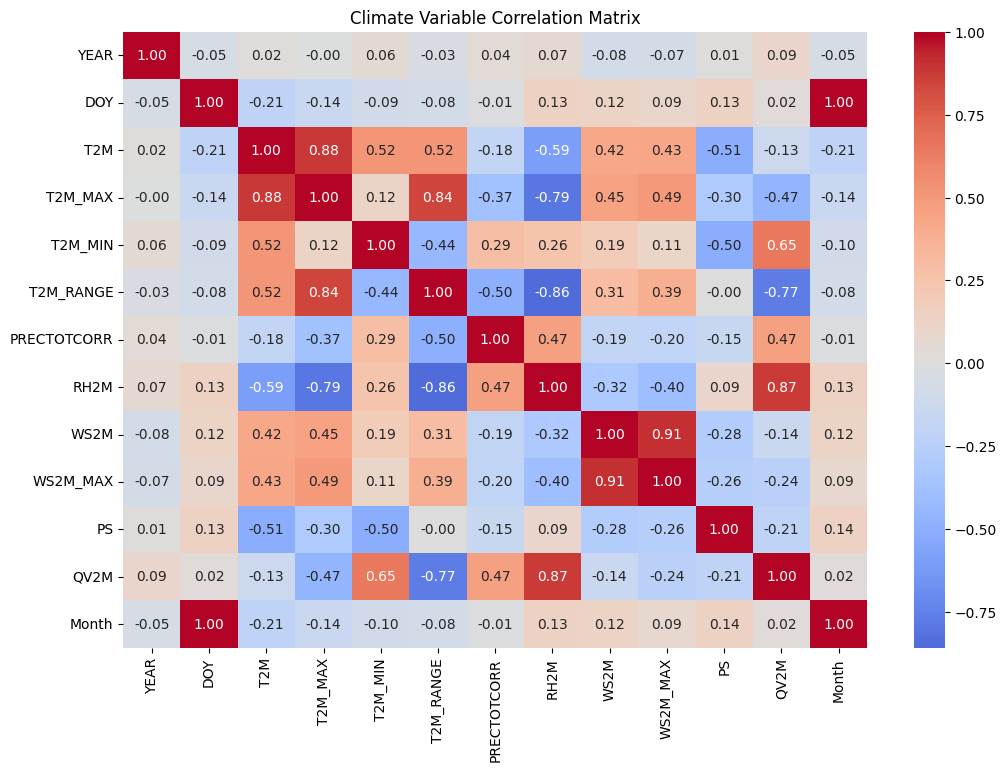

In [40]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
# We only select numeric columns to avoid errors with the Date or Country strings
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Climate Variable Correlation Matrix')
plt.show()

Based on the heatmap, here are the three most significant relationships in the dataset:

Wind Speed (WS2M vs. WS2M_MAX): 0.91
This is a very strong link. It means on days when the normal wind is fast, the strongest wind gusts are also very fast.

Humidity & Water in the Air (RH2M vs. QV2M): 0.87
This strong link shows that when there is more actual water floating in the air, the humidity percentage goes way up.

Temp Change vs. Humidity (T2M_RANGE vs. RH2M): -0.86
This is a strong backwards link. It shows that on days with a huge difference between day and night temperatures, the air is very dry (low humidity). Dry air gets hot and cold much faster than wet air. 

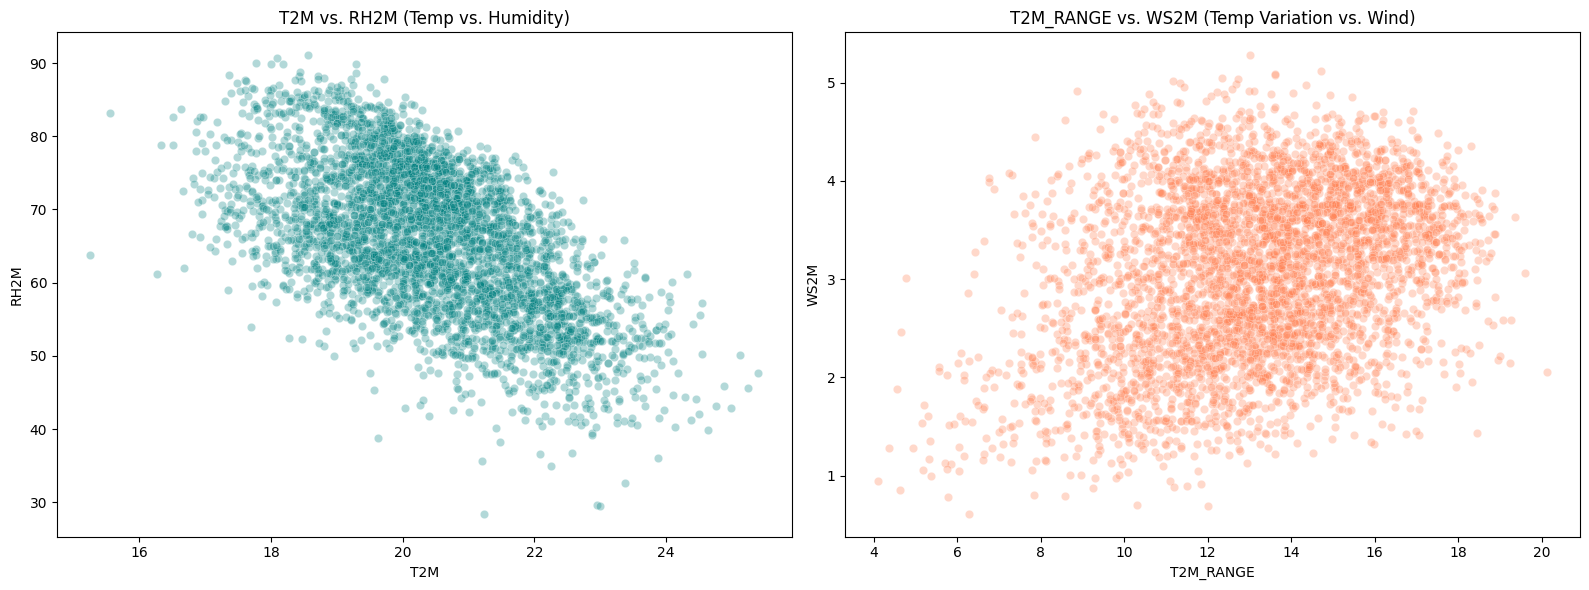

In [41]:
# Scatter plots for specific relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Diurnal Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Temp Variation vs. Wind)')

plt.tight_layout()
plt.show()

Temp vs. Humidity (Left): This chart goes down from left to right. This means as it gets hotter, the air usually gets less humid. Hot air can hold more water, so the humidity percentage drops.

Temp Change vs. Wind Speed (Right): This chart goes slightly up. Days with a big temperature change from day to night also tend to be slightly windier days.

**Distribution Analysis**

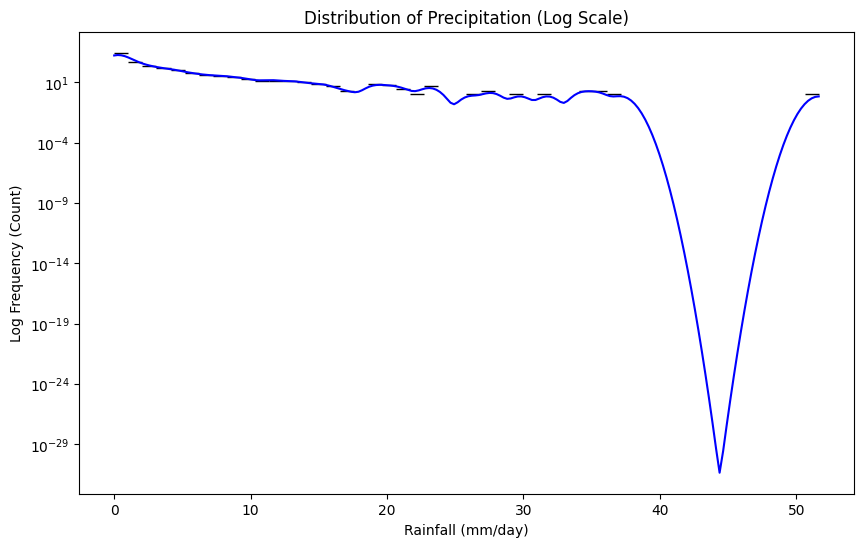

In [42]:
#  Distribution of Rainfall
plt.figure(figsize=(10, 6))
# log_scale=(False, True) means the counts (Y-axis) are log-transformed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='blue', log_scale=(False, True))

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Log Frequency (Count)')
plt.show()

This chart shows that most days have zero rain or very little rain. By using a special view (log scale), we can zoom in to see the rare days. It shows that while they don't happen often, there are huge storms that can drop up to 50 mm of rain in just one day.

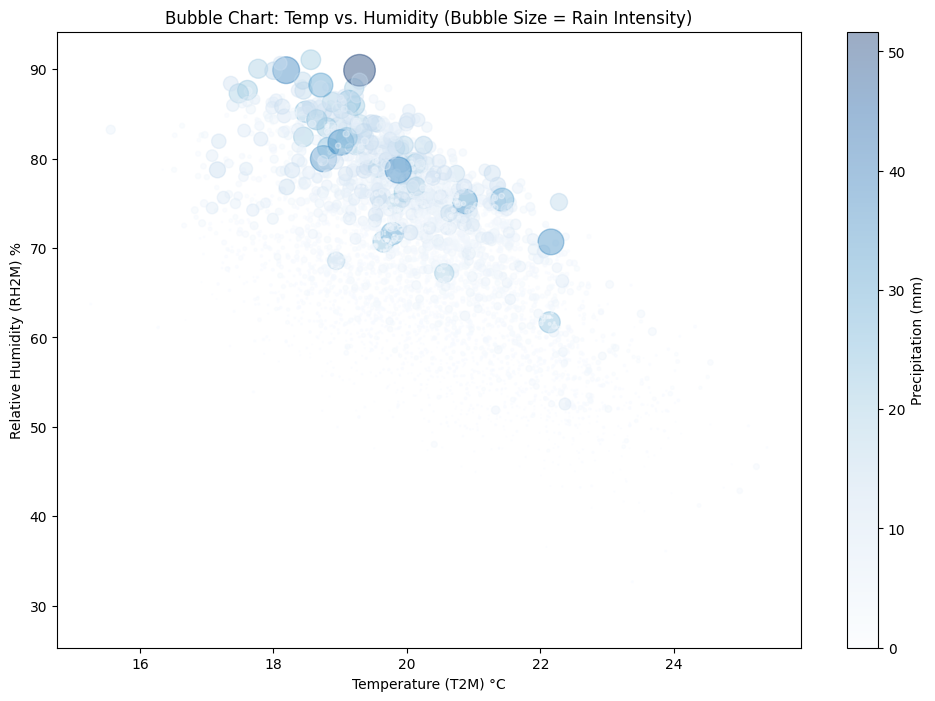

In [43]:
# Bubble Chart: T2M vs. RH2M (Size = PRECTOTCORR)
plt.figure(figsize=(12, 8))

# We multiply PRECTOTCORR by 10 to make the bubbles large enough to see
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 10, 
            alpha=0.4, 
            c=df['PRECTOTCORR'], 
            cmap='Blues')

plt.colorbar(label='Precipitation (mm)')
plt.title('Bubble Chart: Temp vs. Humidity (Bubble Size = Rain Intensity)')
plt.xlabel('Temperature (T2M) °C')
plt.ylabel('Relative Humidity (RH2M) %')
plt.show()

This chart mixes three things to show what a rainy day looks like. The biggest, darkest bubbles (the most rain) are all clumped near the top middle. This means heavy rain almost always happens when the air is very wet (humidity over 75%) and warm but not too hot (between 18°C and 22°C). If it gets too hot and dry (bottom right), there are no bubbles, meaning no rain at all.